> **MTM-only re-score (Fusion_PhD-bhx7.9, 2026-10-02).** The MTM population is GS2-unstable cases the classifier labels MTM (was the fallback E > 0.5 and omega < 0), and capture is T > 0.15 and omega < 0 on the dominant GFTM mode (was E > 0.5). All other cells are the original analysis; the text cells below that quote numbers are the ORIGINAL ones and are superseded by this run's printed output.


# MTM core vs tail: what does GFTM's growth-rate error follow? (Fusion_PhD-bhx7.6)

**Question.** Hardman et al. (2023) describe the MTM as two regions: an inner current layer, which in ballooning space is the extended tail of the eigenfunction, and an outer region, which is the core $|\theta| \lesssim \pi$. Our extent rule sizes GFTM's basis to the eigenfunction's **extent**, a single number dominated by the tail. The working hypothesis (`docs/plans/mtm_core_tail.md` in Fusion_PhD): **extent is reach**, needed to *capture* the tearing branch but not to get its growth rate right; **accuracy** depends on the **core**, or on the tail's integrated response (the tearing parameter $T$). This notebook tests that on the NSTX_MTM `n1000` Latin hypercube, with no new runs.

**Arms.** GFTM `m11_new` (NBASIS 24, NXGRID 30, WIDTH 5.893), the extent rule with envelope margin `s = 1.41` (`extent_rule_tf035_s141`, per-case NXGRID/NBASIS/WIDTH), and `gftm_fw174` (WIDTH 1.74; GFTM ran NXGRID **24**, not the requested 128: `Fusion_PhD-lgp2`). Reference: GS2.

**Per case, all from pyrokinetics:**
- **extent**: pyro `Extent`, the $\theta$ width holding 95% of $\int|F|^2 d\theta$ (full width, in units of $\pi$), GS2 $A_\parallel$ and $\phi$;
- **core fraction** $f_{core} = \int_{|\theta|<\pi}|F|^2 d\theta \,/\, \int_{|\theta|\le 9\pi}|F|^2 d\theta$ for $A_\parallel$ and $\phi$, GS2 and each arm's dominant mode. The same $d\theta$ measure as `Extent`; the denominator is the common window $|\theta| \le 9\pi$ because GFTM prints its eigenfunction on $\pm 9\pi$ whatever its WIDTH (GS2 runs to $\pm 17\pi$);
- **tearing parameter** $T$ and **even fraction** $E$ of $A_\parallel$: `FieldLine.compute_linear_tearing_parameter` / `compute_linear_parity` (pyro #604/#605), GS2 and each GFTM mode;
- **two-scale ratio** $R = $ `Extent(0.95)` / `Extent(0.5)`: 95% width over half-power width. A Gaussian gives 2.91 and an exponential $|F|^2$ 4.32; a core plus a long tail gives more;
- **parallel wavenumber**: pyro's `ConvergenceTestLinear.kpar_fields` builds $k_\parallel$ from $|F|$ (`diagnostics/convergence.py`), so it cannot see phase. Beside it, the $|F|^2$-weighted rms $\theta$-wavenumber from $|F|$ and from the complex $F$: $k_{cplx}^2 = k_{abs}^2 + \langle(\partial_\theta \arg F)^2\rangle$, so the difference is exactly what phase adds. And the Fourier power spectrum of complex $F(\theta)$ and of $|F(\theta)|$.

**MTM population.** The mode-classification function (`Fusion_PhD-7k70`) has **not landed** (its branch is still being calibrated), so the population is the bead's fallback: GS2 unstable ($\gamma > 10^{-3}\,c_s/a$, tail-averaged `pyro_cube_avg`), **tearing parity** ($E > 0.5$, the user's rule of 2026-09-30) **and electron-direction** $\omega < 0$ (pyrokinetics' convention: negative is the electron direction, `gk_code/cgyro.py`, `gene.py`; checked below on the data).

**Tests, per arm** (Spearman $\rho$ with 95% case-bootstrap intervals, and binned medians):
1. Which descriptor does $|\log_{10}(\gamma_{GFTM}/\gamma_{GS2})|$ (dominant mode; a returned $\gamma \le 0$ is a miss scored $+\infty$, never dropped) follow most strongly?
2. Is **capture** (the dominant GFTM mode has tearing parity, $E > 0.5$) governed by reach, and **accuracy on captured cases** by the core or $T$?
3. What fraction of GS2 MTMs are clearly two-scale, and what does phase add to $k_\parallel$?

Advisory numbers for the user's decision, not evidence for a paper.

## Imports and settings

`GK_DATA_ROOT` in `local.env` is the directory holding `GS2/` and `GFTM/`.

In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, norm
from pyrokinetics import Pyro, PyroHypercube
from general_analysis.mode_classification import indicators, classify, T_TEAR
from pyrokinetics.diagnostics.field_line import FieldLine
from pyrokinetics.diagnostics.extent import Extent
from pyrokinetics.diagnostics.convergence import ConvergenceTestLinear

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").is_file() and (path / "notebooks").is_dir()
)
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "mtm_core_tail_mtm_only"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
run_template = "Runs"
project = "LATIN_HYPERCUBE"
case = "NSTX_MTM"
draw = "beta_q_shat_ky_n1000"
check_draw = "beta_q_shat_ky_n300"  # 1yzb's T check samples live here
gs2_reference = "pyro_cube_avg"      # tail-averaged gamma; its eigenfunctions are the complex final-time fields
metadata_file, output_file = "pyroscan.json", "cube.nc"
gs2_file, gftm_file = "gs2.in", "input.gftm"
arms = {"m11_new": "m11_new", "extent rule s=1.41": "extent_rule_tf035_s141", "fw174": "gftm_fw174"}
arm_colours = {"m11_new": "C0", "extent rule s=1.41": "C1", "fw174": "C2"}
fw174_nxgrid = 24  # GFTM reset the requested NXGRID 128 to its default 24 (Fusion_PhD-lgp2, out.gftm.localdump)

gs2_unstable = 1e-3   # c_s/a
parity_cut = 0.5      # apar_even_fraction > 0.5 is tearing parity (user, 2026-09-30)
core = np.pi          # |theta| < pi: the core (outer region); beyond: the ballooning tail (inner layer)
window = 9 * np.pi    # common theta window of GS2 and GFTM for core fractions
gauss_R = norm.ppf(0.975) / norm.ppf(0.75)  # 95% / 50% width of a Gaussian |F|^2: 2.906
expo_R = np.log(20) / np.log(2)             # the same for exponential |F|^2: 4.322
two_scale_cut = 2 * gauss_R                 # "clearly two-scale": R above twice a Gaussian's (agent's choice)
n_uniform = 8192       # uniform theta points for the FFT
envelope_k = 0.5       # rad^-1: |k_theta| below this is the envelope (wavelength > 4pi), above it the 2pi comb
n_bins, n_boot, seed = 6, 2000, 0
# Fusion_PhD-1yzb, n300: T of GS2 and of GFTM m11_new mode 0 on samples 1 (tearing) and 0 (ballooning)
t_check = {"iteration_1": (0.931, 0.429), "iteration_0": (0.0003, 0.167)}

## Load data

The GS2 reference hypercube, with pyro `Extent` over all samples: these are the existing GS2 extents. Then every GS2-unstable run from its own directory: its deck carries the geometry `FieldLine` needs for $T$ and $E$, and pyro `ConvergenceTestLinear` needs the per-run `Pyro` for $k_\parallel$. Fields are the final time point (a shape measure; the runs are converged linear eigenmodes); $\gamma$ and $\omega$ are the cube's tail averages. This loop reads ~800 GS2 outputs.

In [2]:
def plain(da):
    return da.pint.dequantify() if hasattr(da, "pint") else da

def last(da):
    da = plain(da)
    return da.isel(time=-1) if "time" in da.dims else da

gs2_dir = data_root.joinpath("GS2", run_template, project, case, draw)
cube = PyroHypercube(pyroscan_json=gs2_dir / gs2_reference / metadata_file, load_base_pyro=True)
cube.from_netcdf(gs2_dir / gs2_reference / output_file)
Extent(cube.gk_output)
ds = cube.gk_output.data
names = [str(n) for n in ds.sample_name.values]
gamma_gs2 = plain(ds.growth_rate).values.astype(float)
omega_gs2 = plain(ds.mode_frequency).values.astype(float)
cube_extent = {f: plain(ds.extent).sel(field=f).values / np.pi for f in ("apar", "phi")}
unstable = gamma_gs2 > gs2_unstable
print(dict(ds.sizes), f"GS2-unstable {unstable.sum()} of {len(names)}")

{'sample': 1000, 'field': 3, 'theta': 2177, 'species': 2, 'bound': 2} GS2-unstable 904 of 1000


In [3]:
gs2 = {}
for i in np.flatnonzero(unstable):
    pyro = Pyro(gk_file=gs2_dir / names[i] / gs2_file)
    pyro.load_gk_output(load_moments=False)
    out = pyro.gk_output
    fl = FieldLine(pyro)
    r = dict(label=classify(indicators(pyro)), E=float(plain(fl.compute_linear_parity()).values.ravel()[0]),
             T=float(plain(fl.compute_linear_tearing_parameter()).values.ravel()[0]),
             theta=plain(out["theta"]).values,
             **{f: last(out[f]).isel(kx=0, ky=0).values for f in ("apar", "phi")})
    for frac in (0.95, 0.5):
        Extent(out, fraction=frac)
        r[frac] = {f: float(last(out["extent"]).sel(field=f).values.ravel()[0]) / np.pi for f in ("apar", "phi")}
    if r["E"] > parity_cut and omega_gs2[i] < 0:
        r["kpar"] = ConvergenceTestLinear(pyro).kpar_fields
    gs2[names[i]] = r
print(len(gs2), "GS2 runs read")

/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


904 GS2 runs read


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


### Checks: GS2 extent, the omega sign, and T against `Fusion_PhD-1yzb`

The per-run final-time `Extent` should reproduce the cube's. The sign check: tearing-parity cases on this MTM database should sit overwhelmingly at $\omega < 0$ if negative is the electron direction.

In [4]:
run_ext = np.array([gs2[n][0.95]["apar"] for n in gs2])
ref_ext = np.array([cube_extent["apar"][names.index(n)] for n in gs2])
rel = np.abs(run_ext / ref_ext - 1)
print(f"A_par extent, per-run vs cube: median |rel diff| {np.median(rel):.2e}, max {rel.max():.2e}, n={rel.size}; "
      f"> 1e-3: {[(n, round(a, 3), round(b, 3)) for n, a, b, r in zip(gs2, run_ext, ref_ext, rel) if r > 1e-3]}")

E_gs2 = np.array([gs2[n]["E"] if n in gs2 else np.nan for n in names])
tear = unstable & (E_gs2 > parity_cut)
print(f"omega < 0: {np.mean(omega_gs2[tear] < 0):.3f} of {tear.sum()} tearing-parity cases, "
      f"{np.mean(omega_gs2[unstable & ~tear] < 0):.3f} of {(unstable & ~tear).sum()} ballooning-parity cases")

for sample, (t_gs2, t_gftm) in t_check.items():
    got = []
    for code, leaf, file in (("GS2", "", gs2_file), ("GFTM", "m11_new", gftm_file)):
        pyro = Pyro(gk_file=data_root.joinpath(code, run_template, project, case, check_draw, leaf, sample, file))
        pyro.load_gk_output(**({"load_fluxes": False, "load_moments": False} if code == "GS2" else {}))
        got.append(plain(FieldLine(pyro).compute_linear_tearing_parameter()).values.ravel()[0])
    print(f"n300 {sample}: T GS2 {got[0]:.4f} (1yzb {t_gs2}), GFTM m11_new mode 0 {got[1]:.4f} (1yzb {t_gftm})")

A_par extent, per-run vs cube: median |rel diff| 2.48e-04, max 4.83e-01, n=904; > 1e-3: [('iteration_12', np.float64(9.459), np.float64(9.448)), ('iteration_16', np.float64(0.919), np.float64(0.903)), ('iteration_19', np.float64(14.404), np.float64(14.26)), ('iteration_20', np.float64(0.569), np.float64(0.558)), ('iteration_22', np.float64(0.551), np.float64(0.54)), ('iteration_25', np.float64(1.07), np.float64(1.061)), ('iteration_26', np.float64(1.104), np.float64(1.1)), ('iteration_29', np.float64(0.722), np.float64(0.71)), ('iteration_31', np.float64(0.557), np.float64(0.539)), ('iteration_37', np.float64(0.834), np.float64(0.817)), ('iteration_39', np.float64(0.788), np.float64(0.778)), ('iteration_40', np.float64(0.185), np.float64(0.158)), ('iteration_44', np.float64(0.899), np.float64(0.892)), ('iteration_47', np.float64(1.071), np.float64(1.054)), ('iteration_49', np.float64(26.976), np.float64(27.042)), ('iteration_50', np.float64(0.567), np.float64(0.556)), ('iteration_55', 

n300 iteration_1: T GS2 0.9308 (1yzb 0.931), GFTM m11_new mode 0 0.4294 (1yzb 0.429)


n300 iteration_0: T GS2 0.0003 (1yzb 0.0003), GFTM m11_new mode 0 0.1668 (1yzb 0.167)


### The MTM population and the GFTM arms

Each arm is read run by run for the population (GFTM carries one eigenfunction per mode; `FieldLine` gives $T$ and $E$ per mode). The dominant mode is the `argmax` of $\gamma$ over `mode`. A case whose run directory has no GFTM output (the extent rule's infeasible cases) is a **miss**, listed and scored $+\infty$, never dropped. The arm's reach is the outermost Hermite node, $\mathrm{WIDTH}\cdot x_{max}(2\,\mathrm{NXGRID}-1)$, from each run's deck (`fw174` at the NXGRID it ran).

In [5]:
label_gs2 = np.array([gs2[n]["label"] if n in gs2 else "" for n in names])
mtm = unstable & (label_gs2 == "MTM")
print(f"removed {len(names) - int(mtm.sum())} of {len(names)}: GS2-stable {int((~unstable).sum())}, KBM {int((label_gs2 == 'KBM').sum())}, mixed {int((label_gs2 == 'mixed').sum())}; fallback (E>0.5 & omega<0) population was {int((unstable & tear & (omega_gs2 < 0)).sum())}, overlap {int((mtm & tear & (omega_gs2 < 0)).sum())}")
pop = [names[i] for i in np.flatnonzero(mtm)]
print(f"MTM population (GS2 unstable, E > {parity_cut}, omega < 0): {len(pop)} of {len(names)}")

gftm, missing = {}, {}
for arm, leaf in arms.items():
    missing[arm] = []
    for n in pop:
        run = data_root.joinpath("GFTM", run_template, project, case, draw, leaf, n)
        if not (run / "out.gftm.wavefunction").is_file():
            missing[arm].append(n)
            continue
        pyro = Pyro(gk_file=run / gftm_file)
        pyro.load_gk_output()
        out, fl = pyro.gk_output, FieldLine(pyro)
        g = last(out["growth_rate"]).isel(kx=0, ky=0, missing_dims="ignore").values.astype(float)
        k = int(np.nanargmax(g))
        nx = fw174_nxgrid if leaf == "gftm_fw174" else int(pyro.gk_input.data["nxgrid"])
        gftm[arm, n] = dict(
            gamma=g[k],
            omega=float(last(out["mode_frequency"]).isel(kx=0, ky=0, missing_dims="ignore").values.astype(float)[k]),
            E=float(last(plain(fl.compute_linear_parity())).isel(kx=0, ky=0, missing_dims="ignore").values[k]),
            T=float(last(plain(fl.compute_linear_tearing_parameter())).isel(kx=0, ky=0, missing_dims="ignore").values[k]),
            theta=plain(out["theta"]).values,
            reach=float(pyro.gk_input.data["width"]) * np.polynomial.hermite.hermgauss(2 * nx - 1)[0].max() / np.pi,
            **{f: last(out[f]).isel(kx=0, ky=0, mode=k, missing_dims="ignore").values for f in ("apar", "phi")})
    print(f"{arm}: read {sum(a == arm for a, _ in gftm)}, no output {len(missing[arm])} {missing[arm][:5]}")

removed 289 of 1000: GS2-stable 96, KBM 136, mixed 57; fallback (E>0.5 & omega<0) population was 743, overlap 711
MTM population (GS2 unstable, E > 0.5, omega < 0): 711 of 1000


m11_new: read 711, no output 0 []


extent rule s=1.41: read 702, no output 9 ['iteration_217', 'iteration_263', 'iteration_477', 'iteration_510', 'iteration_559']


fw174: read 711, no output 0 []


## Calculate

Descriptors per case. `core_fraction` and `k_theta` act on one field on its own $\theta$ grid; `spectrum` interpolates onto a uniform grid for the FFT (GS2's $\theta$ grid is not uniform).

In [6]:
def core_fraction(theta, F):
    m = np.abs(theta) <= window
    w = np.abs(F[m]) ** 2
    return np.trapezoid(w * (np.abs(theta[m]) < core), theta[m]) / np.trapezoid(w, theta[m])

def k_theta(theta, F):
    """|F|^2-weighted rms theta-wavenumber from |F| (phase-blind, as pyro's kpar) and from complex F."""
    norm2 = np.trapezoid(np.abs(F) ** 2, theta)
    k_abs = np.sqrt(np.trapezoid(np.gradient(np.abs(F), theta) ** 2, theta) / norm2)
    k_cplx = np.sqrt(np.trapezoid(np.abs(np.gradient(F, theta)) ** 2, theta) / norm2)
    return k_abs, k_cplx

def spectrum(theta, F):
    u = np.linspace(theta[0], theta[-1], n_uniform)
    Fu = np.interp(u, theta, F.real) + 1j * np.interp(u, theta, F.imag)
    k = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(n_uniform, u[1] - u[0]))
    power = lambda f: np.fft.fftshift(np.abs(np.fft.fft(f)) ** 2)
    return k, power(Fu), power(np.abs(Fu))

In [7]:
d = {}  # descriptor name -> array over pop
d["extent A_par [pi]"] = np.array([gs2[n][0.95]["apar"] for n in pop])
d["extent phi [pi]"] = np.array([gs2[n][0.95]["phi"] for n in pop])
d["f_core A_par"] = np.array([core_fraction(gs2[n]["theta"], gs2[n]["apar"]) for n in pop])
d["f_core phi"] = np.array([core_fraction(gs2[n]["theta"], gs2[n]["phi"]) for n in pop])
d["two-scale R A_par"] = d["extent A_par [pi]"] / np.array([gs2[n][0.5]["apar"] for n in pop])
d["two-scale R phi"] = d["extent phi [pi]"] / np.array([gs2[n][0.5]["phi"] for n in pop])
kt = {f: np.array([k_theta(gs2[n]["theta"], gs2[n][f]) for n in pop]) for f in ("apar", "phi")}
d["k_par pyro A_par"] = np.array([gs2[n]["kpar"]["apar"] for n in pop])
d["k_theta |A_par|"], d["k_theta A_par complex"] = kt["apar"].T
d["k_theta phi complex"] = kt["phi"][:, 1]
T_gs2 = np.array([gs2[n]["T"] for n in pop])
gamma_ref = np.array([gamma_gs2[names.index(n)] for n in pop])

case_descriptors = ["extent A_par [pi]", "extent phi [pi]", "f_core A_par", "f_core phi", "two-scale R A_par",
                    "k_par pyro A_par", "k_theta |A_par|", "k_theta A_par complex"]
per_arm = {}
for arm in arms:
    have = np.array([(arm, n) in gftm for n in pop])
    get = lambda key: np.array([gftm[arm, n][key] if (arm, n) in gftm else np.nan for n in pop])
    g = get("gamma")
    with np.errstate(divide="ignore", invalid="ignore"):
        err = np.where(have & (g > 0), np.abs(np.log10(g / gamma_ref)), np.inf)
    fc = np.array([core_fraction(gftm[arm, n]["theta"], gftm[arm, n]["apar"]) if (arm, n) in gftm else np.nan
                   for n in pop])
    per_arm[arm] = dict(err=err, capture=have & (g > 0) & (get("omega") < 0) & (get("T") > T_TEAR),
                        **{"|T_GFTM - T_GS2|": np.abs(get("T") - T_gs2),
                           "|f_core A_par GFTM - GS2|": np.abs(fc - d["f_core A_par"]),
                           "extent / reach": d["extent A_par [pi]"] / 2 / get("reach")})
    reach = get("reach")
    print(f"{arm}: reach [pi] min/median/max {np.nanmin(reach):.1f}/{np.nanmedian(reach):.1f}/{np.nanmax(reach):.1f}, "
          f"Spearman(extent, reach) {spearmanr(d['extent A_par [pi]'], reach, nan_policy='omit')[0]:+.2f}")
    print(f"{arm}: misses {np.isinf(err).sum()}, capture {per_arm[arm]['capture'].mean():.3f}, "
          f"medlog {np.median(err):.3f}, median T {np.nanmedian(get('T')):.3f} (GS2 {np.median(T_gs2):.3f})")

m11_new: reach [pi] min/median/max 18.9/18.9/18.9, Spearman(extent, reach) +nan
m11_new: misses 10, capture 0.717, medlog 0.281, median T 0.379 (GS2 0.795)
extent rule s=1.41: reach [pi] min/median/max 3.3/9.1/37.2, Spearman(extent, reach) +0.79
extent rule s=1.41: misses 29, capture 0.789, medlog 0.352, median T 0.536 (GS2 0.795)
fw174: reach [pi] min/median/max 4.9/4.9/4.9, Spearman(extent, reach) +nan
fw174: misses 61, capture 0.498, medlog 0.478, median T 0.408 (GS2 0.795)


/tmp/ipykernel_3684258/3346976010.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  f"Spearman(extent, reach) {spearmanr(d['extent A_par [pi]'], reach, nan_policy='omit')[0]:+.2f}")


### Statistics

Spearman $\rho$ between each descriptor and each outcome, with 95% intervals from 2000 case-bootstrap resamples. The same resamples are used for every descriptor of an arm, so $|\rho|$ differences between descriptors are paired. Misses ($+\infty$) are kept and rank last. $|T_{GFTM}-T_{GS2}|$ and $|\Delta f_{core}|$ use GFTM's own output: they diagnose *where* the error sits, they are not a-priori predictors.

Outcomes: **error** = the log-ratio on the whole population; **capture** = 0/1; **accuracy | captured** = the log-ratio on captured cases only.

In [8]:
rng = np.random.default_rng(seed)
arm_descriptors = ["|T_GFTM - T_GS2|", "|f_core A_par GFTM - GS2|", "extent / reach"]

def rho_table(x, y):
    """{descriptor: (rho, ci, n, boot)}. One set of case resamples for every descriptor (paired);
    each descriptor uses the cases where it is finite (a run with no output has no T or reach)."""
    keep = ~np.isnan(y)
    b = rng.integers(0, keep.sum(), (n_boot, keep.sum()))
    res = {}
    for name, v in x.items():
        v, w = v[keep], y[keep]
        ok = np.isfinite(v)
        rho = lambda i: spearmanr(v[i][ok[i]], w[i][ok[i]])[0]
        boot = np.array([rho(i) for i in b])
        res[name] = (rho(np.arange(v.size)), np.nanpercentile(boot, [2.5, 97.5]), int(ok.sum()), boot)
    return res

stats = {}
for arm, a in per_arm.items():
    x = {**{k: d[k] for k in case_descriptors}, **{k: a[k] for k in arm_descriptors}}
    stats[arm, "error"] = rho_table(x, a["err"])
    stats[arm, "capture"] = rho_table(x, a["capture"].astype(float))
    stats[arm, "accuracy | captured"] = rho_table(x, np.where(a["capture"], a["err"], np.nan))

for (arm, outcome), res in stats.items():
    order = sorted(res, key=lambda k: -abs(res[k][0]))
    best = order[0]
    print(f"\n{arm} | {outcome} (n={res[best][2]})")
    for k in order:
        rho, ci, n, boot = res[k]
        diff = np.nanpercentile(np.abs(res[best][3]) - np.abs(boot), [2.5, 97.5])
        print(f"  {k:28s} n={n:4d} rho {rho:+.3f} [{ci[0]:+.3f}, {ci[1]:+.3f}]   |rho_best|-|rho| [{diff[0]:+.3f}, {diff[1]:+.3f}]")


m11_new | error (n=711)
  f_core phi                   n= 711 rho +0.575 [+0.515, +0.628]   |rho_best|-|rho| [+0.000, +0.000]
  extent A_par [pi]            n= 711 rho -0.495 [-0.556, -0.431]   |rho_best|-|rho| [+0.037, +0.122]
  extent / reach               n= 711 rho -0.495 [-0.556, -0.431]   |rho_best|-|rho| [+0.037, +0.122]
  f_core A_par                 n= 711 rho +0.484 [+0.418, +0.545]   |rho_best|-|rho| [+0.054, +0.128]
  extent phi [pi]              n= 711 rho -0.409 [-0.477, -0.340]   |rho_best|-|rho| [+0.122, +0.213]
  two-scale R A_par            n= 711 rho +0.263 [+0.188, +0.334]   |rho_best|-|rho| [+0.244, +0.381]
  |T_GFTM - T_GS2|             n= 701 rho +0.259 [+0.182, +0.335]   |rho_best|-|rho| [+0.222, +0.410]
  |f_core A_par GFTM - GS2|    n= 701 rho +0.235 [+0.163, +0.306]   |rho_best|-|rho| [+0.255, +0.429]
  k_theta A_par complex        n= 711 rho -0.124 [-0.198, -0.052]   |rho_best|-|rho| [+0.348, +0.550]
  k_theta |A_par|              n= 711 rho -0.121 [-0.195,

### Test 3: two scales and phase

Two-scale fraction from $R$; what phase adds, as $k_{cplx}/k_{abs}$; pyro's `kpar` against $k_{abs}$ (it should track it: same $|F|$ information, plus pyro's $\hat b\cdot\nabla\theta$ and Jacobian weighting); and the share of spectral power at envelope scales ($|k_\theta| < 0.5$, wavelength $> 4\pi$) for complex $A_\parallel$ and for $|A_\parallel|$.

In [9]:
for f in ("A_par", "phi"):
    R = d[f"two-scale R {f}"]
    print(f"{f}: R median {np.median(R):.2f} [IQR {np.percentile(R, 25):.2f}-{np.percentile(R, 75):.2f}]; "
          f"R > exponential ({expo_R:.2f}) {np.mean(R > expo_R):.3f}; clearly two-scale R > {two_scale_cut:.2f}: "
          f"{np.mean(R > two_scale_cut):.3f} of {R.size}")
for f in ("apar", "phi"):
    ratio = kt[f][:, 1] / kt[f][:, 0]
    print(f"{f}: k_cplx / k_abs median {np.median(ratio):.2f} [IQR {np.percentile(ratio, 25):.2f}-"
          f"{np.percentile(ratio, 75):.2f}]; phase > half of k_cplx^2: {np.mean(ratio > np.sqrt(2)):.3f}")
print(f"Spearman pyro kpar(A_par) vs k_abs: {spearmanr(d['k_par pyro A_par'], d['k_theta |A_par|'])[0]:.3f}, "
      f"vs k_cplx: {spearmanr(d['k_par pyro A_par'], d['k_theta A_par complex'])[0]:.3f}")

spectra = {n: spectrum(gs2[n]["theta"], gs2[n]["apar"]) for n in pop}
# The spectra are a comb at integer k_theta (2pi-periodic structure along the field line), so peak counting
# does not separate scales. Instead: the power fraction at envelope scales, wavelength > 4pi.
envelope = np.array([[P[np.abs(k) < envelope_k].sum() / P.sum() for P in (Pc, Pa)] for k, Pc, Pa in spectra.values()])
print(f"A_par power fraction at |k_theta| < {envelope_k}: complex median {np.median(envelope[:, 0]):.3f}, "
      f"|A_par| median {np.median(envelope[:, 1]):.3f}")
two = d["two-scale R A_par"] > two_scale_cut
print(f"  clearly two-scale (n={two.sum()}): complex {np.median(envelope[two, 0]):.3f}; "
      f"others {np.median(envelope[~two, 0]):.3f}")

A_par: R median 3.10 [IQR 2.27-5.88]; R > exponential (4.32) 0.309; clearly two-scale R > 5.81: 0.253 of 711
phi: R median 3.39 [IQR 2.34-4.66]; R > exponential (4.32) 0.326; clearly two-scale R > 5.81: 0.084 of 711
apar: k_cplx / k_abs median 1.01 [IQR 1.00-1.02]; phase > half of k_cplx^2: 0.000
phi: k_cplx / k_abs median 1.16 [IQR 1.11-1.27]; phase > half of k_cplx^2: 0.158
Spearman pyro kpar(A_par) vs k_abs: 0.847, vs k_cplx: 0.847


A_par power fraction at |k_theta| < 0.5: complex median 0.272, |A_par| median 0.341
  clearly two-scale (n=180): complex 0.208; others 0.298


## Plot

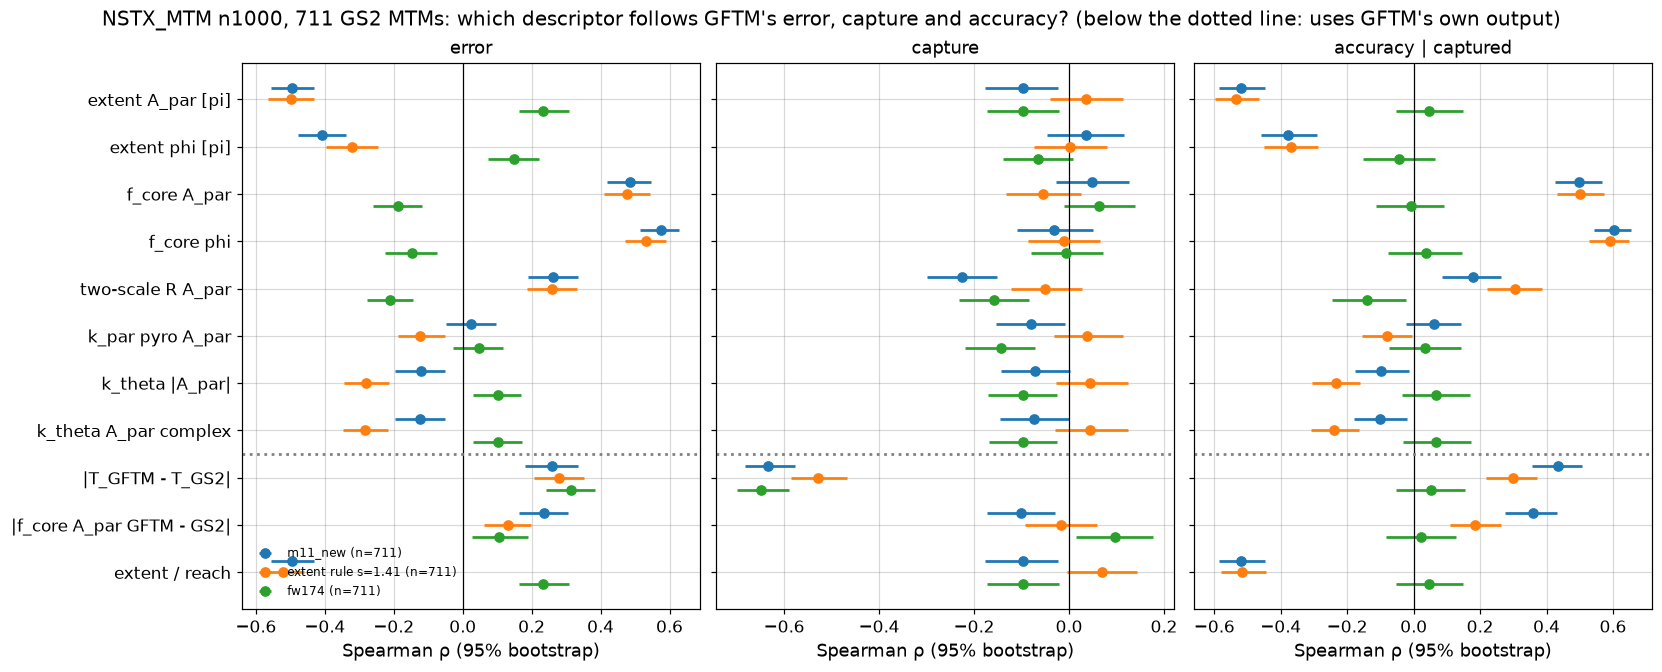

In [10]:
figs = {}
outcomes = ["error", "capture", "accuracy | captured"]
labels = case_descriptors + arm_descriptors
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
for ax, outcome in zip(axes, outcomes):
    for j, arm in enumerate(arms):
        res = stats[arm, outcome]
        y = np.arange(len(labels)) + (j - 1) * 0.25
        rho = np.array([res[k][0] for k in labels])
        ci = np.array([res[k][1] for k in labels])
        ax.errorbar(rho, y, xerr=np.abs(ci - rho[:, None]).T, ls="", color=arm_colours[arm],
                    label=f"{arm} (n={res[labels[0]][2]})")
    ax.axvline(0, color="k", lw=0.8, marker="")
    ax.axhline(len(case_descriptors) - 0.5, color="grey", ls=":", marker="")
    ax.set(title=outcome, xlabel="Spearman ρ (95% bootstrap)")
axes[0].set(yticks=range(len(labels)), yticklabels=labels)
axes[0].invert_yaxis()
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle(f"NSTX_MTM n1000, {len(pop)} GS2 MTMs: which descriptor follows GFTM's error, capture and "
             "accuracy? (below the dotted line: uses GFTM's own output)")
figs["fig1_spearman_summary"] = fig

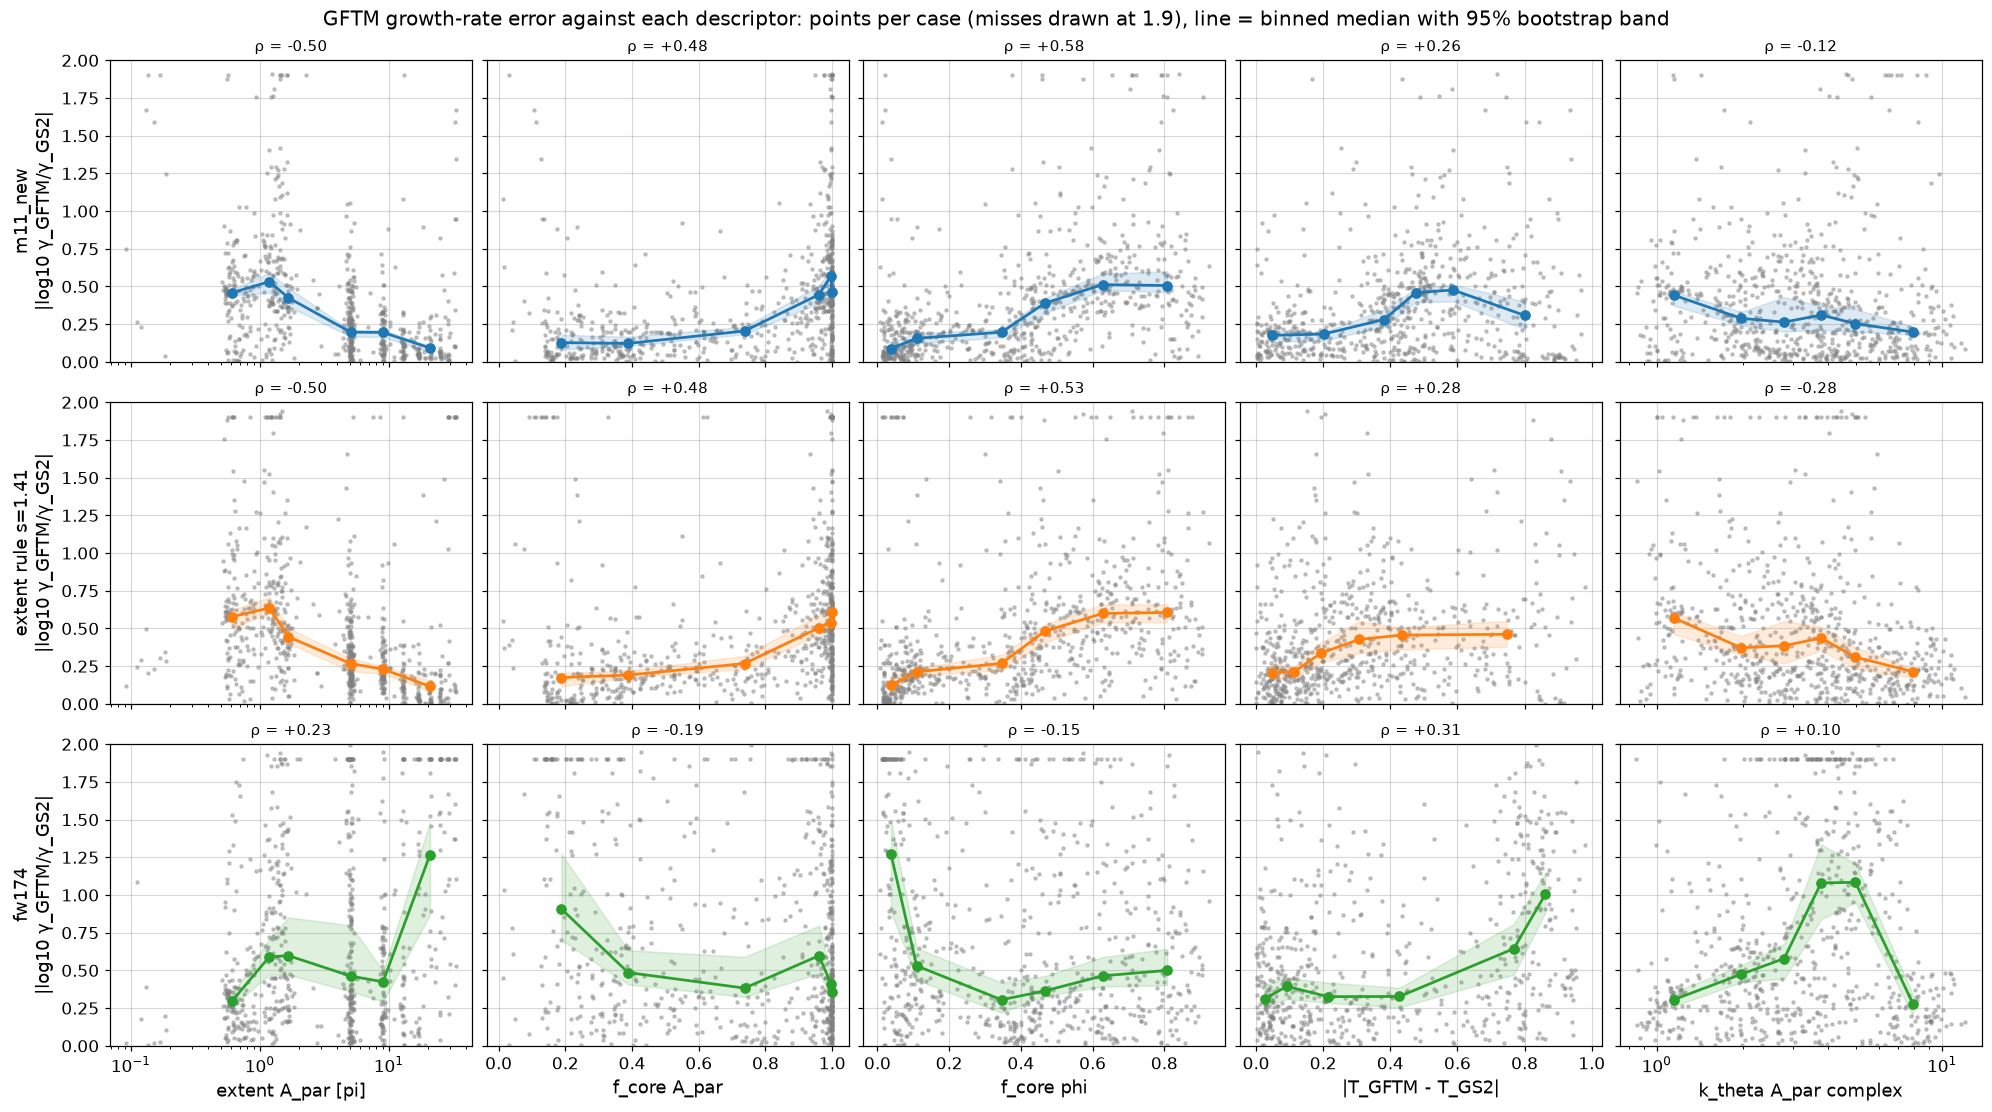

In [11]:
def binned(ax, x, y, colour, stat=np.median, logx=False):
    ok = np.isfinite(x) & ~np.isnan(y)
    edges = np.nanpercentile(x[ok], np.linspace(0, 100, n_bins + 1))
    mids, med, ci = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = ok & (x >= lo) & (x <= hi)
        b = rng.integers(0, m.sum(), (n_boot, m.sum()))
        mids.append(np.median(x[m])); med.append(stat(y[m])); ci.append(np.percentile(stat(y[m][b], axis=1), [2.5, 97.5]))
    ci = np.array(ci)
    ax.plot(mids, med, color=colour)
    ax.fill_between(mids, ci[:, 0], ci[:, 1], color=colour, alpha=0.15)
    if logx:
        ax.set_xscale("log")

cols = ["extent A_par [pi]", "f_core A_par", "f_core phi", "|T_GFTM - T_GS2|", "k_theta A_par complex"]
fig, axes = plt.subplots(len(arms), len(cols), figsize=(18, 10), sharey=True, sharex="col")
for i, (arm, a) in enumerate(per_arm.items()):
    for j, c in enumerate(cols):
        x = d[c] if c in d else a[c]
        ax = axes[i, j]
        ax.scatter(x, np.where(np.isinf(a["err"]), 1.9, a["err"]), s=4, color="grey", alpha=0.4)
        binned(ax, x, a["err"], arm_colours[arm], logx=c.startswith("extent") or c.startswith("k_theta"))
        ax.set_title(f"ρ = {stats[arm, 'error'][c][0]:+.2f}", fontsize=10)
        axes[-1, j].set_xlabel(c)
    axes[i, 0].set_ylabel(f"{arm}\n|log10 γ_GFTM/γ_GS2|")
axes[0, 0].set_ylim(0, 2)
fig.suptitle("GFTM growth-rate error against each descriptor: points per case (misses drawn at 1.9), line = binned "
             "median with 95% bootstrap band")
figs["fig2_error_vs_descriptors"] = fig

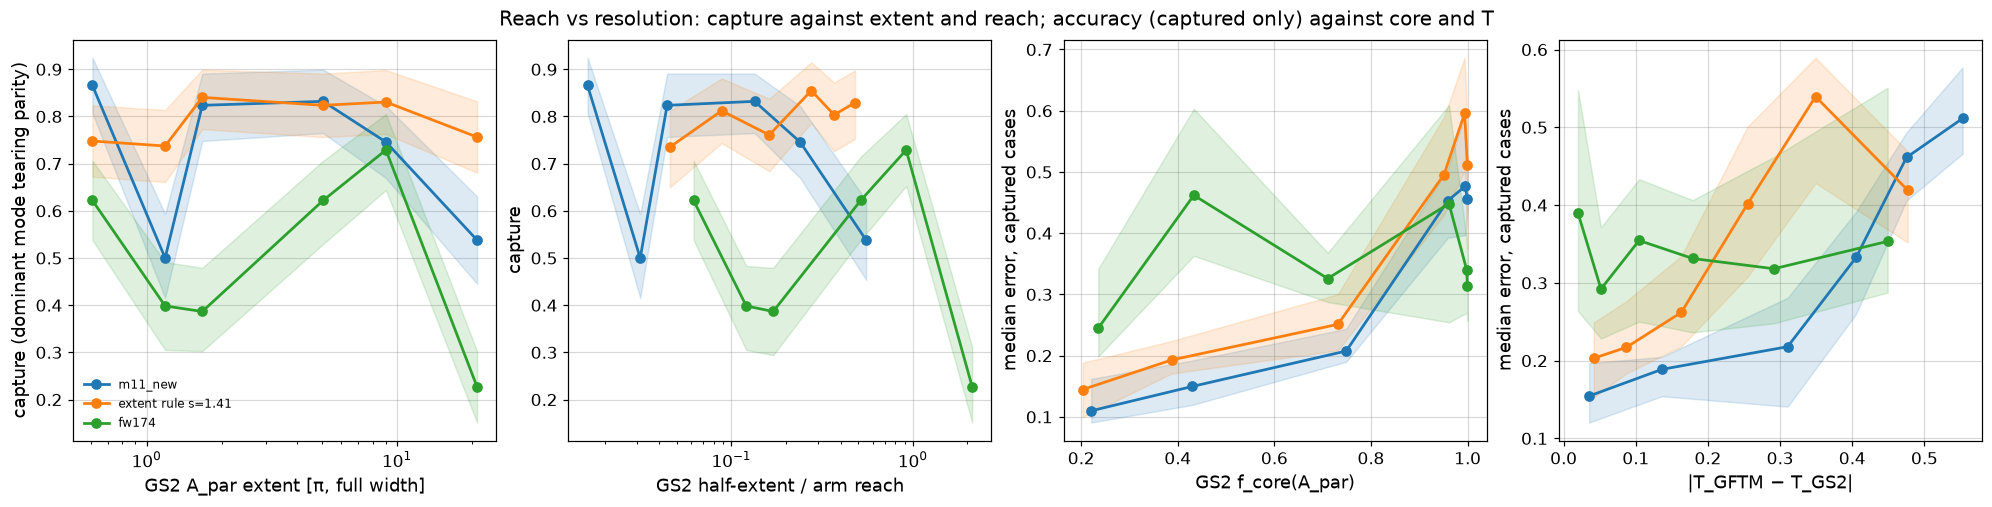

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for arm, a in per_arm.items():
    binned(axes[0], d["extent A_par [pi]"], a["capture"].astype(float), arm_colours[arm], stat=np.mean, logx=True)
    binned(axes[1], a["extent / reach"], a["capture"].astype(float), arm_colours[arm], stat=np.mean, logx=True)
    acc = np.where(a["capture"], a["err"], np.nan)
    binned(axes[2], d["f_core A_par"], acc, arm_colours[arm])
    binned(axes[3], a["|T_GFTM - T_GS2|"], acc, arm_colours[arm])
axes[0].set(xlabel="GS2 A_par extent [π, full width]", ylabel="capture (dominant mode tearing parity)")
axes[1].set(xlabel="GS2 half-extent / arm reach", ylabel="capture")
axes[2].set(xlabel="GS2 f_core(A_par)", ylabel="median error, captured cases")
axes[3].set(xlabel="|T_GFTM − T_GS2|", ylabel="median error, captured cases")
axes[0].legend(handles=[plt.Line2D([], [], color=c, label=a) for a, c in arm_colours.items()], fontsize=8)
fig.suptitle("Reach vs resolution: capture against extent and reach; accuracy (captured only) against core and T")
figs["fig3_capture_vs_accuracy"] = fig

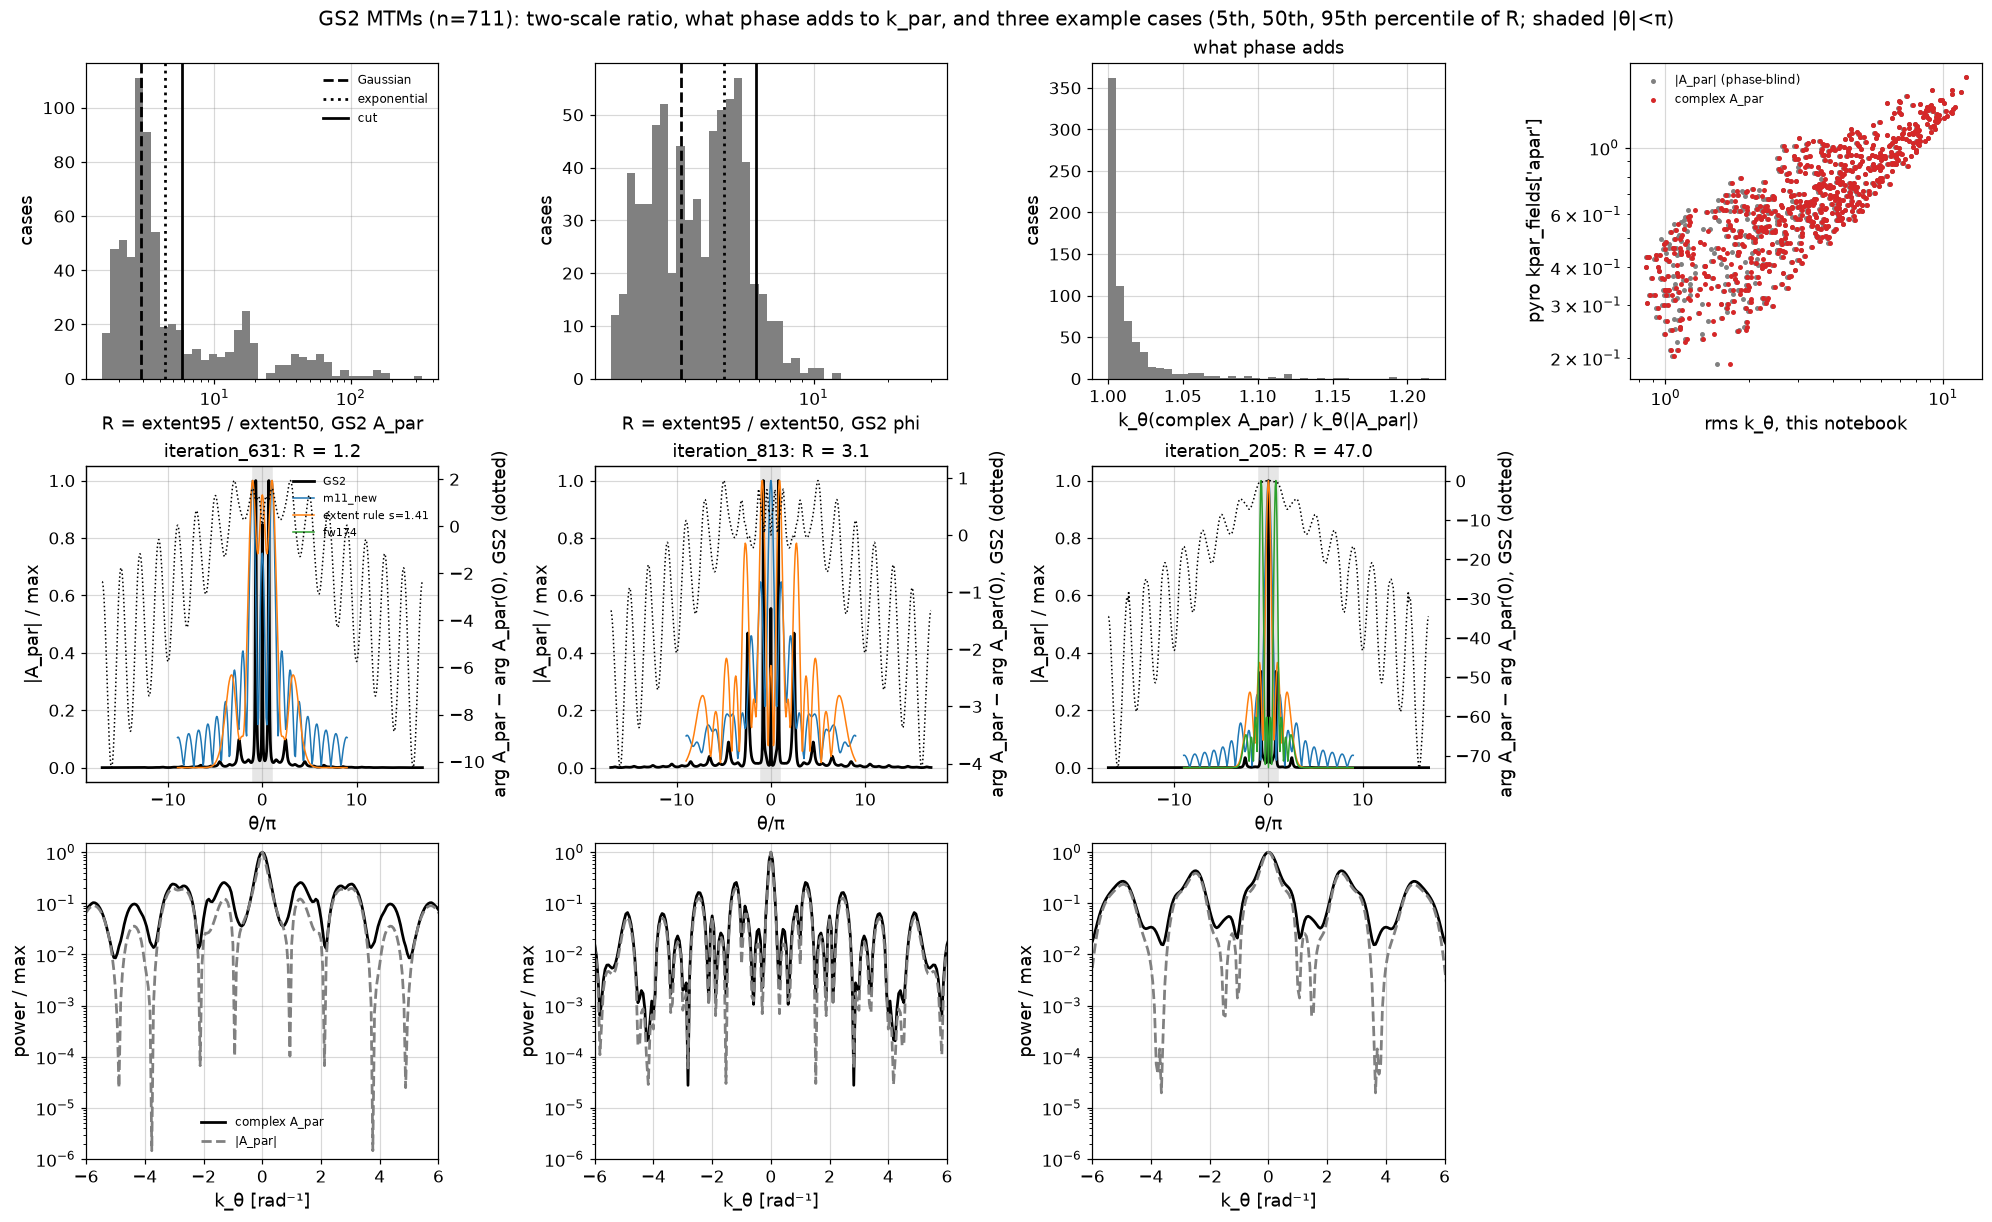

In [13]:
R = d["two-scale R A_par"]
examples = [pop[i] for i in np.argsort(R)[[len(R) // 20, len(R) // 2, -len(R) // 20]]]
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, f in zip(axes[0, :2], ("A_par", "phi")):
    ax.hist(d[f"two-scale R {f}"], bins=np.geomspace(1.5, max(30, d[f"two-scale R {f}"].max()), 40), color="grey")
    for v, lab, ls in ((gauss_R, "Gaussian", "--"), (expo_R, "exponential", ":"), (two_scale_cut, "cut", "-")):
        ax.axvline(v, color="k", ls=ls, marker="", label=lab)
    ax.set(xscale="log", xlabel=f"R = extent95 / extent50, GS2 {f}", ylabel="cases")
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
axes[0, 0].legend(fontsize=8)
ratio = kt["apar"][:, 1] / kt["apar"][:, 0]
axes[0, 2].hist(ratio, bins=40, color="grey")
axes[0, 2].set(xlabel="k_θ(complex A_par) / k_θ(|A_par|)", ylabel="cases", title="what phase adds")
axes[0, 3].scatter(d["k_theta |A_par|"], d["k_par pyro A_par"], s=5, color="grey", label="|A_par| (phase-blind)")
axes[0, 3].scatter(d["k_theta A_par complex"], d["k_par pyro A_par"], s=5, color="C3", label="complex A_par")
axes[0, 3].set(xscale="log", yscale="log", xlabel="rms k_θ, this notebook", ylabel="pyro kpar_fields['apar']")
axes[0, 3].legend(fontsize=8)
for j, n in enumerate(examples):
    th = gs2[n]["theta"] / np.pi
    ax = axes[1, j]
    ax.plot(th, np.abs(gs2[n]["apar"]) / np.abs(gs2[n]["apar"]).max(), color="k", marker="", label="GS2")
    for arm in arms:
        if (arm, n) in gftm:
            a = gftm[arm, n]["apar"]
            ax.plot(gftm[arm, n]["theta"] / np.pi, np.abs(a) / np.abs(a).max(), color=arm_colours[arm], marker="",
                    lw=1, label=arm)
    ax.axvspan(-1, 1, color="0.9", zorder=0)
    ax.set(xlabel="θ/π", ylabel="|A_par| / max", title=f"{n}: R = {R[pop.index(n)]:.1f}")
    ph = np.unwrap(np.angle(gs2[n]["apar"]))
    tw = ax.twinx()
    tw.plot(th, ph - np.interp(0, th, ph), color="k", ls=":", marker="", lw=1)
    tw.set_ylabel("arg A_par − arg A_par(0), GS2 (dotted)")
    tw.grid(False)
    k, Pc, Pa = spectra[n]
    axes[2, j].plot(k, Pc / Pc.max(), color="k", marker="", label="complex A_par")
    axes[2, j].plot(k, Pa / Pa.max(), color="grey", ls="--", marker="", label="|A_par|")
    axes[2, j].set(xlim=(-6, 6), yscale="log", ylim=(1e-6, 1.5), xlabel="k_θ [rad⁻¹]", ylabel="power / max")
axes[1, 0].legend(fontsize=7)
axes[2, 0].legend(fontsize=8)
axes[1, 3].axis("off"); axes[2, 3].axis("off")
fig.suptitle(f"GS2 MTMs (n={len(pop)}): two-scale ratio, what phase adds to k_par, and three example cases "
             "(5th, 50th, 95th percentile of R; shaded |θ|<π)")
figs["fig4_two_scale_and_phase"] = fig
plt.show()

## Save

In [14]:
output_dir = ROOT / "Plots" / analysis_name
output_dir.mkdir(parents=True, exist_ok=True)
for name, fig in figs.items():
    fig.savefig(output_dir / f"{name}.png", dpi=150, bbox_inches="tight")
print(sorted(p.name for p in output_dir.glob("*.png")))

['fig1_spearman_summary.png', 'fig2_error_vs_descriptors.png', 'fig3_capture_vs_accuracy.png', 'fig4_two_scale_and_phase.png']


## Interpretation

Filled in after the run from the printed tables: see Fusion_PhD `results/mtm_core_tail/README.md`.